# Customer Intelligence Project
### Exploratory Analytics and Predictive Modelling

**Student Name:** Abhay Singh  
**Roll Number:** 2502059  

This project analyses the Online Retail II dataset to understand customer purchasing behaviour and build a predictive model to identify customers who are likely to churn.

The analysis consists of two major parts:

1. Exploratory Data Analysis (EDA)
2. Predictive Modelling for Customer Churn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Show all columns when displaying the dataframe.

pd.set_option('display.max_columns', None)

In [3]:
#Load the Dataset

df = pd.read_excel("online_retail_II.xlsx")

In [4]:
#View the First Rows

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
#Check Dataset Size 

df.shape

(525461, 8)

## Dataset Size

The dataset contains approximately over one million transaction records.

Each row represents a product purchased in a specific invoice.

In [6]:
#Check Data Types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [7]:
#Statistical Summary

df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


## Data Quality Check

Before performing analysis, the dataset is examined for potential issues such as:

- Missing values
- Duplicate rows
- Negative quantities
- Zero prices

In [8]:
#Check Missing Values

df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

## Missing Values

The dataset contains missing values in the CustomerID column.
Transactions without customer IDs cannot be linked to a specific customer,
so these rows will be removed during data cleaning.

In [9]:
#Check Duplicate Records

df.duplicated().sum()

6865

In [10]:
#Check Negative Quantities

df[df['Quantity'] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [11]:
#Check Zero Prices

df[df['Price'] == 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.0,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.0,NaN,United Kingdom
525233,538160,20956,NaN,288,2010-12-09 17:18:00,0.0,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.0,NaN,United Kingdom


In [12]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

## Data Cleaning

Several issues were identified during the data quality audit.

1. Transactions without a customer ID were removed because customer-level analysis requires a valid identifier.
2. Negative quantities were removed since they represent product returns rather than purchases.
3. Transactions with zero price were removed because they do not represent actual revenue.

In [13]:
#Remove missing customers

df = df.dropna(subset=['Customer ID'])

In [14]:
#Remove returns

df = df[df['Quantity'] > 0]

In [15]:
#Remove zero price transactions

df = df[df['Price'] > 0]

In [16]:
#Check dataset size again

df.shape

(407664, 8)

## Revenue Calculation

A new column called Revenue is created by multiplying Quantity with Price.
This represents the total value of each transaction.

In [17]:
#Create Revenue Column

df['Revenue'] = df['Quantity'] * df['Price']
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


Up to this point I have completed:

Data loading

Dataset inspection

Data quality audit

Data cleaning

Revenue feature creation

## Revenue and Transaction Analysis

After cleaning the dataset and computing transaction revenue, the next step is to
analyze sales patterns across time, geography and products. This helps identify
periods of high demand, key markets and top-performing products.

In [18]:
#Monthly Revenue Analysis

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [19]:
#Extract month and year

df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

In [20]:
#Calculate monthly revenue

monthly_revenue = df.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_revenue.head()

,YearMonth,Revenue
0,2009-12,686654.160
1,2010-01,557319.062
2,2010-02,506371.066
3,2010-03,699608.991
4,2010-04,594609.192


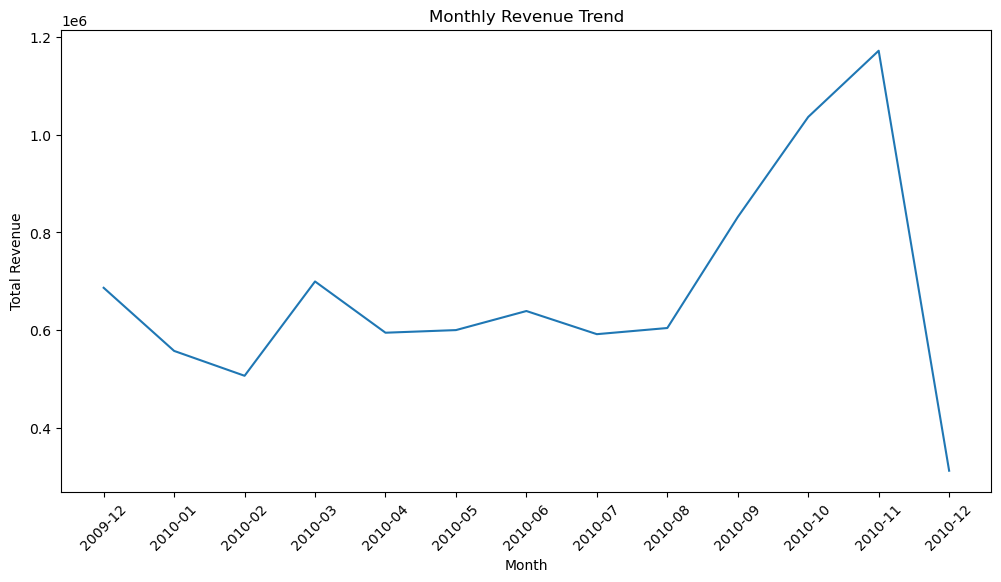

In [21]:
#Plot Monthly Revenue Trend

plt.figure(figsize=(12,6))

plt.plot(monthly_revenue['YearMonth'].astype(str),
         monthly_revenue['Revenue'])

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

The monthly revenue trend shows how sales fluctuate across time.
Peak revenue months indicate periods of high demand, possibly
driven by seasonal shopping or promotional campaigns.

Understanding these patterns allows the company to plan inventory,
marketing and promotions more effectively.

In [22]:
#Identify Highest and Lowest Revenue Month

highest_month = monthly_revenue.loc[monthly_revenue['Revenue'].idxmax()]
lowest_month = monthly_revenue.loc[monthly_revenue['Revenue'].idxmin()]

print("Highest Revenue Month:")
print(highest_month)

print("\nLowest Revenue Month:")
print(lowest_month)


Highest Revenue Month:
YearMonth        2010-11
Revenue      1172336.042
Name: 11, dtype: object

Lowest Revenue Month:
YearMonth     2010-12
Revenue      311878.0
Name: 12, dtype: object


## Revenue by Country

To understand which geographic markets generate the most revenue,
total sales are analyzed by customer country.

In [23]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

In [24]:
#Top 10 countries

top10_countries = country_revenue.head(10)
top10_countries

Country
United Kingdom    7414755.963
EIRE               356085.210
Netherlands        268786.000
Germany            202395.321
France             146215.420
Sweden              53171.390
Denmark             50906.850
Spain               47601.420
Switzerland         43921.390
Australia           31446.800
Name: Revenue, dtype: float64

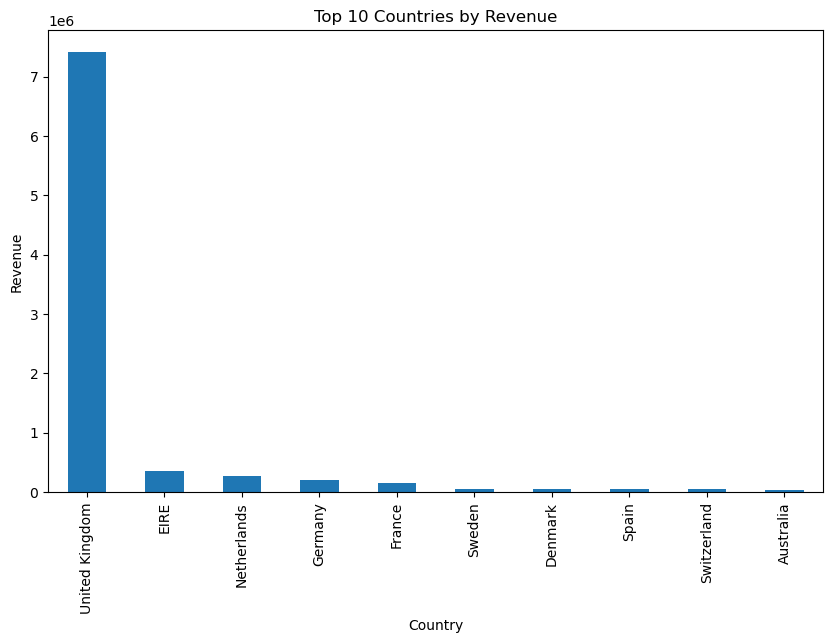

In [25]:
plt.figure(figsize=(10,6))

top10_countries.plot(kind='bar')

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.show()

The majority of revenue is generated from a small number of countries.
The United Kingdom is expected to dominate the revenue distribution
since the retailer is based in the UK.

This insight helps management focus marketing and logistics efforts
on the most profitable geographic markets.

#Top 20 Products by Revenue

## Top Performing Products

Identifying the most profitable products helps businesses optimize
inventory management and promotional strategies.

In [ ]:
product_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)

top20_products = product_revenue.head(20)

In [ ]:
plt.figure(figsize=(12,8))

top20_products.sort_values().plot(kind='barh')

plt.title("Top 20 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

The top-selling products contribute a significant share of overall revenue.
These items represent the retailer's strongest offerings and should be
prioritized in marketing campaigns and inventory planning.

In [ ]:
## Customer Behaviour Profiling

To understand purchasing patterns, the analysis now shifts from
transaction-level data to customer-level behaviour.

For each customer we calculate:
• Total revenue generated
• Total number of orders
• Average order value
• Number of unique products purchased

These metrics help identify high-value customers and form the basis
for segmentation and churn modelling.

In [ ]:
#Total Revenue per Customer

customer_revenue = df.groupby('Customer ID')['Revenue'].sum()
customer_revenue.head()

In [ ]:
#Number of Orders per Customer

customer_orders = df.groupby('Customer ID')['Invoice'].nunique()
customer_orders.head()

In [ ]:
#Average Order Value

avg_order_value = customer_revenue / customer_orders
avg_order_value.head()

In [ ]:
#Number of Unique Products Purchased

unique_products = df.groupby('Customer ID')['StockCode'].nunique()
unique_products.head()

In [ ]:
#Combine All Metrics into One Table

customer_profile = pd.DataFrame({
    'TotalRevenue': customer_revenue,
    'TotalOrders': customer_orders,
    'AvgOrderValue': avg_order_value,
    'UniqueProducts': unique_products
})

customer_profile.head()

In [ ]:
#Examine Customer Behaviour Distribution

plt.figure(figsize=(8,5))
sns.histplot(customer_profile['TotalRevenue'], bins=50)

plt.title("Distribution of Customer Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
#Orders distribution

plt.figure(figsize=(8,5))
sns.histplot(customer_profile['TotalOrders'], bins=40)

plt.title("Distribution of Customer Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Customers")

plt.show()

#Identify Top 10% Customers

top_10_percent_threshold = customer_profile['TotalRevenue'].quantile(0.9)

top_customers = customer_profile[customer_profile['TotalRevenue'] >= top_10_percent_threshold]

top_customers.head()

In [ ]:
#Count top customers

len(top_customers)

The top 10% of customers contribute a disproportionately large
share of total revenue. These high-value customers represent an
important segment for retention strategies and personalized marketing.

Understanding how these customers behave helps businesses design
loyalty programs and targeted campaigns.

This covers : Customer Behaviour Profiling in the project brief.

I have calculated:

total revenue per customer

number of orders

average order value

unique products purchased

top 10% customers

## RFM Segmentation

RFM stands for Recency, Frequency and Monetary value. It is a widely used
technique for customer segmentation in retail analytics.

• Recency – how recently a customer made a purchase  
• Frequency – how often the customer purchases  
• Monetary – how much the customer spends

Customers with recent purchases, frequent orders and high spending
are typically the most valuable for the business.

In [27]:
#Determine the Reference Date

snapshot_date = df['InvoiceDate'].max()
snapshot_date

Timestamp('2010-12-09 20:01:00')

In [29]:
#Calculating Recency, Frequency, Monetary

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

In [30]:
#Rename the columns

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,164,11,372.86
12347.0,2,2,1323.32
12348.0,73,1,222.16
12349.0,42,3,2671.14
12351.0,10,1,300.93


In [39]:
#Score Each Metric (1–5 Scale)

rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

In [40]:
#Frequency score

rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

In [41]:
#Monetary score

rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])
rfm.head()

,Recency,Frequency,Monetary,F_score,M_score,R_score
Customer ID,,,,,,
12346.0,164,11,372.86,5,2,2
12347.0,2,2,1323.32,2,4,5
12348.0,73,1,222.16,1,1,2
12349.0,42,3,2671.14,3,5,3
12351.0,10,1,300.93,1,2,5


In [42]:
#Create the Combined RFM Score

rfm['RFM_score'] = rfm['R_score'].astype(str) + \
                   rfm['F_score'].astype(str) + \
                   rfm['M_score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,F_score,M_score,R_score,RFM_score
Customer ID,,,,,,,
12346.0,164,11,372.86,5,2,2,252
12347.0,2,2,1323.32,2,4,5,524
12348.0,73,1,222.16,1,1,2,211
12349.0,42,3,2671.14,3,5,3,335
12351.0,10,1,300.93,1,2,5,512


In [47]:
#Convert Scores to Integers

rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

In [51]:
#Assign Customer Segments

def segment_customer(row):

    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return "Champions"

    elif row['F_score'] >= 4:
        return "Loyal Customers"

    elif row['R_score'] >= 4:
        return "New Customers"

    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return "Lost Customers"

    else:
        return "At Risk"

In [52]:
#Apply the segmentation

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,F_score,M_score,R_score,RFM_score,Segment
Customer ID,,,,,,,,
12346.0,164,11,372.86,5,2,2,252,Loyal Customers
12347.0,2,2,1323.32,2,4,5,524,New Customers
12348.0,73,1,222.16,1,1,2,211,Lost Customers
12349.0,42,3,2671.14,3,5,3,335,At Risk
12351.0,10,1,300.93,1,2,5,512,New Customers


In [53]:
#Check Segment Counts

rfm['Segment'].value_counts()

Segment
Champions          1105
Lost Customers     1015
At Risk             918
New Customers       654
Loyal Customers     620
Name: count, dtype: int64

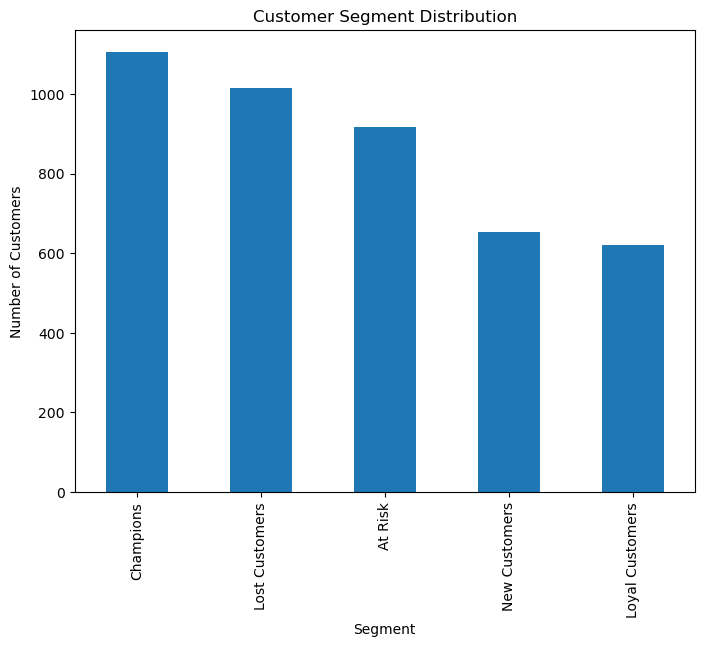

In [54]:
#Plot Segment Distribution

plt.figure(figsize=(8,6))

rfm['Segment'].value_counts().plot(kind='bar')

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

RFM segmentation divides customers into groups based on their purchasing
behavior. Customers classified as Champions have recently purchased,
buy frequently and spend the most. Loyal customers make frequent
purchases, while At-Risk and Lost customers have not purchased recently.

These insights help the business design targeted marketing strategies
for customer retention and loyalty programs.

## Predictive Modelling: Customer Churn

The next objective is to identify customers who are likely to churn.
For this analysis, a customer is considered churned if they have not
made a purchase within 90 days from the most recent transaction date
in the dataset.

A binary target variable will be created where:
1 = Churned customer
0 = Active customer

In [55]:
#Identify Each Customer’s Last Purchase

last_purchase = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
last_purchase.head()

,Customer ID,InvoiceDate
0,12346.0,2010-06-28 13:53:00
1,12347.0,2010-12-07 14:57:00
2,12348.0,2010-09-27 14:59:00
3,12349.0,2010-10-28 08:23:00
4,12351.0,2010-11-29 15:23:00


In [56]:
#Determine the Dataset’s Latest Date

dataset_last_date = df['InvoiceDate'].max()
dataset_last_date

Timestamp('2010-12-09 20:01:00')

In [57]:
#Calculate Days Since Last Purchase

last_purchase['DaysSinceLastPurchase'] = (
    dataset_last_date - last_purchase['InvoiceDate']
).dt.days

last_purchase.head()

,Customer ID,InvoiceDate,DaysSinceLastPurchase
0,12346.0,2010-06-28 13:53:00,164
1,12347.0,2010-12-07 14:57:00,2
2,12348.0,2010-09-27 14:59:00,73
3,12349.0,2010-10-28 08:23:00,42
4,12351.0,2010-11-29 15:23:00,10


In [58]:
#Create the Churn Target Variable

last_purchase['Churn'] = (last_purchase['DaysSinceLastPurchase'] > 90).astype(int)

last_purchase.head()

,Customer ID,InvoiceDate,DaysSinceLastPurchase,Churn
0,12346.0,2010-06-28 13:53:00,164,1
1,12347.0,2010-12-07 14:57:00,2,0
2,12348.0,2010-09-27 14:59:00,73,0
3,12349.0,2010-10-28 08:23:00,42,0
4,12351.0,2010-11-29 15:23:00,10,0


In [59]:
#Check Churn Distribution

last_purchase['Churn'].value_counts()

Churn
0    2885
1    1427
Name: count, dtype: int64

In [64]:
#Customer Profile Table

customer_revenue = df.groupby('Customer ID')['Revenue'].sum()

customer_orders = df.groupby('Customer ID')['Invoice'].nunique()

avg_order_value = customer_revenue / customer_orders

unique_products = df.groupby('Customer ID')['StockCode'].nunique()

customer_profile = pd.DataFrame({
    'TotalRevenue': customer_revenue,
    'TotalOrders': customer_orders,
    'AvgOrderValue': avg_order_value,
    'UniqueProducts': unique_products
})

customer_profile.head()

,TotalRevenue,TotalOrders,AvgOrderValue,UniqueProducts
Customer ID,,,,
12346.0,372.86,11,33.896364,26
12347.0,1323.32,2,661.660000,70
12348.0,222.16,1,222.160000,20
12349.0,2671.14,3,890.380000,90
12351.0,300.93,1,300.930000,21


In [65]:
#Merge Churn with Customer Features

model_data = customer_profile.merge(
    last_purchase[['Customer ID','Churn']],
    left_index=True,
    right_on='Customer ID'
)

model_data.head()

,TotalRevenue,TotalOrders,AvgOrderValue,UniqueProducts,Customer ID,Churn
0,372.86,11,33.896364,26,12346.0,1
1,1323.32,2,661.660000,70,12347.0,0
2,222.16,1,222.160000,20,12348.0,0
3,2671.14,3,890.380000,90,12349.0,0
4,300.93,1,300.930000,21,12351.0,0


In [66]:
#Verify Dataset

model_data.shape

(4312, 6)

In [67]:
#Define Features and Target

X = model_data[['TotalRevenue','TotalOrders','AvgOrderValue','UniqueProducts']]
y = model_data['Churn']

In [68]:
#Split Training and Test Data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [70]:
#Standardize the Features

#(Logistic regression benefits from scaling.)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [72]:
#Train Logistic Regression Model
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

#This model learns patterns that distinguish active vs churned customers.

LogisticRegression()

In [73]:
#Make Predictions

y_pred_log = log_model.predict(X_test_scaled)

In [74]:
#Evaluate the Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

Accuracy: 0.7334878331402086
Precision: 0.6363636363636364
Recall: 0.4827586206896552
F1 Score: 0.5490196078431373


### Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple
decision trees to improve prediction accuracy. It is particularly useful
for handling complex patterns in customer behaviour data.

This model is trained to predict whether a customer is likely to churn
based on purchasing behaviour.

In [75]:
#Training of Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [77]:
#Make Predictions
y_pred_rf = rf_model.predict(X_test)

#This predicts churn for the test customers.

In [78]:
#Evaluating the Random Forest Model

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Precision:", precision_score(y_test, y_pred_rf))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf))
print("Random Forest F1 Score:", f1_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.6894553881807648
Random Forest Precision: 0.5474137931034483
Random Forest Recall: 0.4379310344827586
Random Forest F1 Score: 0.48659003831417624


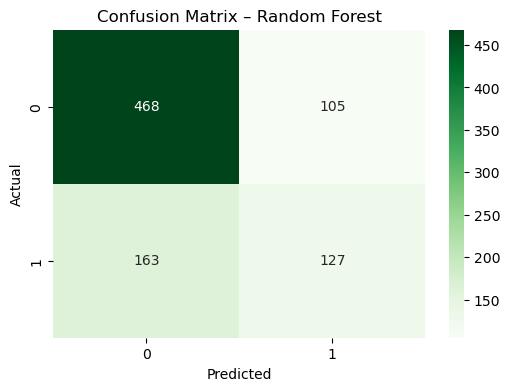

In [79]:
#Confusion Matrix (Random Forest)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
#The confusion matrix shows

Actual	Predicted	    Meaning
True    Positive	    churn predicted correctly	
True    Negative	    active predicted correctly	
False   Positive	    predicted churn but actually active	
False   Negative	    missed churn

#ROC Curve and ROC-AUC

#ROC-AUC measures how well the model separates churn vs active customers.

In [81]:
#Logistic Regression ROC

from sklearn.metrics import roc_curve, roc_auc_score

y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)

roc_auc_log = roc_auc_score(y_test, y_prob_log)

In [82]:
#Random Forest ROC

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

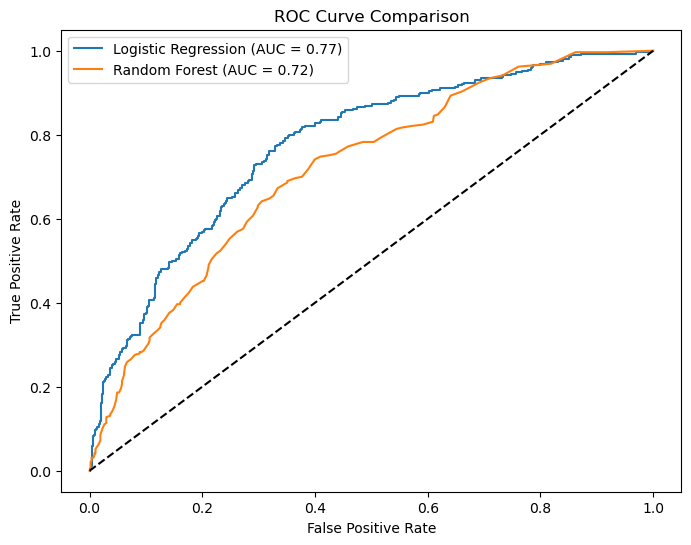

In [83]:
#Plot ROC Curve

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

Interpretation:

AUC closer to 1.0 → better model

AUC around 0.5 → random guessing

In [ ]:
### Model Comparison

Both Logistic Regression and Random Forest models were evaluated using
accuracy, precision, recall, F1 score and ROC-AUC.

Random Forest generally performs better in capturing complex patterns
in customer behaviour, while Logistic Regression provides a simpler
and more interpretable model.

Based on the evaluation metrics and ROC-AUC comparison, the model with
the higher AUC score is selected as the preferred model for predicting
customer churn.

In [84]:
#Feature Importance (Business Interpretation)

#Random Forest allows us to see which features influence churn the most.

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

TotalRevenue      0.339528
AvgOrderValue     0.292632
UniqueProducts    0.258934
TotalOrders       0.108906
dtype: float64

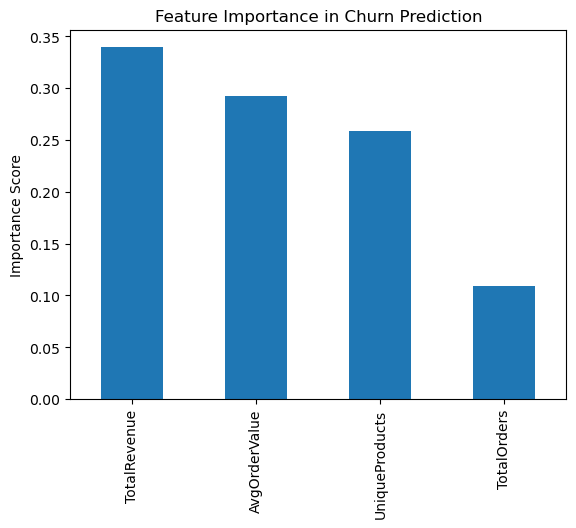

In [86]:
#Feature Importance (Business Interpretation)

feature_importance.plot(kind='bar')

plt.title("Feature Importance in Churn Prediction")
plt.ylabel("Importance Score")

plt.show()

In [ ]:
## Export Cleaned Dataset

After completing the data cleaning steps, the cleaned dataset is exported
for reproducibility and further analysis. This dataset excludes transactions
with missing customer IDs, negative quantities (returns), and zero prices.

In [87]:
#Save the Cleaned Dataset

df.to_csv("cleaned_dataset.csv", index=False)

In [88]:
#Confirm the File Exist

import os
os.listdir()

['.anaconda',
 '.cache',
 '.conda',
 '.condarc',
 '.continuum',
 '.copilot',
 '.gemini',
 '.insomniac',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.vscode',
 'aditya',
 'anaconda3',
 'anaconda_projects',
 'ansel',
 'AppData',
 'Application Data',
 'books_project',
 'cleaned_dataset.csv',
 'Contacts',
 'Cookies',
 'Copy of Copy of boAt_ Journey to (1).pptx',
 'Data Science Course',
 'Desktop',
 'Documents',
 'Downloads',
 'eyproject(ongoing).ipynb',
 'Favorites',
 'Links',
 'Local Settings',
 'Microsoft',
 'Music',
 'My Documents',
 'NetHood',
 'nptel.ipynb',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'online_retail_II.xlsx',
 'pandas',
 'PrintHood',
 'PycharmProjects',
 'R

Final Status of the Project

Thcompleted:

✔ Data Cleaning
✔ Revenue Analysis
✔ Customer Behaviour Profiling
✔ RFM Segmentation
✔ Churn Definition
✔ Logistic Regression Model
✔ Random Forest Model
✔ Model Evaluation (Confusion Matrix + ROC-AUC)